# End-to-End Sales Forecasting & Demand Intelligence System

## Internship Project – Week 3 & Week 4

### Objective
The objective of this project is to build an intelligent sales forecasting system capable of predicting future product demand, detecting unusual sales patterns, segmenting products based on demand behavior, and presenting insights through an interactive dashboard.

This project covers data preprocessing, exploratory data analysis (EDA), time series analysis, forecasting using multiple models, anomaly detection, clustering, dashboard development using Streamlit, and business reporting.

# Task 1: Data Loading, Merging & Deep Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [7]:
file_path = r"C:\Users\mrpar\Downloads\Telegram Desktop\train.csv"
df = pd.read_csv(file_path)
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9800, 18)


In [9]:
print("Column Names:\n")
print(df.columns)

Column Names:

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [11]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## Data Quality Assessment

In [12]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
#date columns to datetime coversion
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

## Feature Engineering

In [17]:
df["Year"]= df["Order Date"].dt.year
df["Month"]= df["Order Date"].dt.month
df["Month Name"]= df["Order Date"].dt.month_name()
df["Week Number"]= df["Order Date"].dt.isocalendar().week
df["Day of Week"]= df["Order Date"].dt.day_name()
df["Quarter"]= df["Order Date"].dt.quarter

In [19]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"
df["Season"] = df["Month"].apply(get_season)

In [20]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,11,November,45,Wednesday,4,Autumn


## Sales Aggregation

In [21]:
daily_sales=df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [22]:
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [23]:
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [24]:
print("Daily Sales Shape :",daily_sales.shape)
print("Weekly Sales Shape:",weekly_sales.shape)
print("Monthly Sales Shape:",monthly_sales.shape)

Daily Sales Shape : (1230, 2)
Weekly Sales Shape: (209, 2)
Monthly Sales Shape: (48, 2)


## Business Question 1: Which Product Category Generates the Highest Total Revenue?

In [25]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

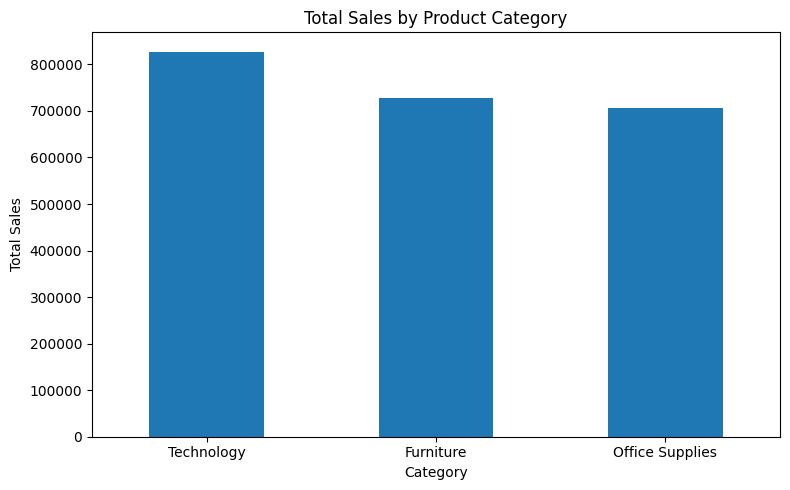

In [35]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/category_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The **Technology** category generated the highest total revenue among all product categories.
- **Furniture** ranked second, while **Office Supplies** generated the lowest total revenue.
- This indicates that Technology products contribute the most to overall business revenue and should remain a key focus for inventory planning and forecasting.

## Business Question 2: Which Region Has the Most Consistent Sales Growth Over Four Years?

In [27]:
region_yearly_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .unstack()
)
region_yearly_sales

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


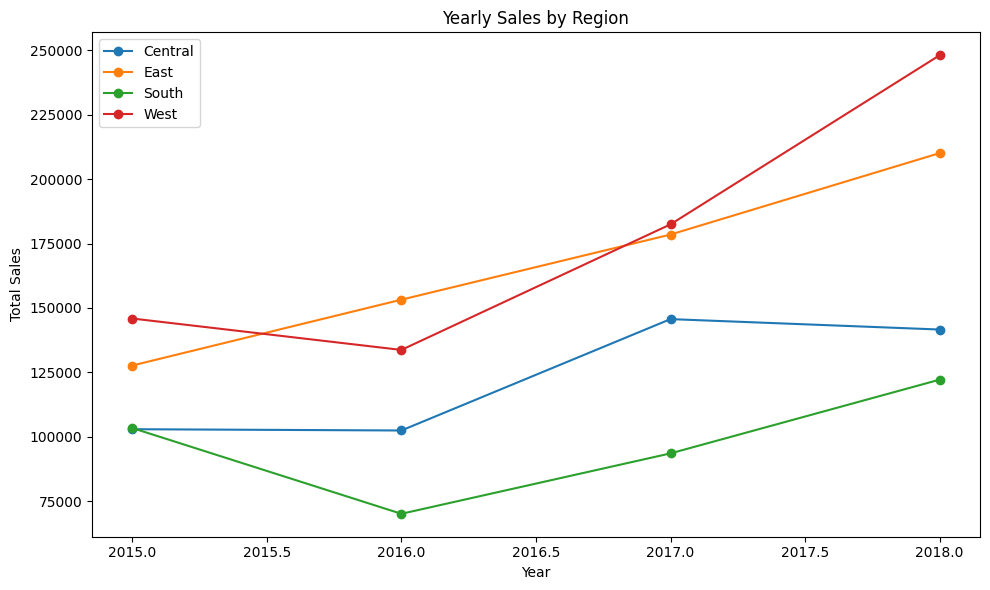

In [36]:
plt.figure(figsize=(10,6))
for region in region_yearly_sales.columns:
    plt.plot(
        region_yearly_sales.index,
        region_yearly_sales[region],
        marker="o",
        label=region
    )
plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.savefig("charts/yearly_sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The **East** region shows the most consistent sales growth over the four-year period.
- Although the **West** region records the highest sales by 2018, it experiences a decline between 2015 and 2016, making its growth less consistent.
- The East region demonstrates a steady upward trend, indicating stable business performance over time.

## Business Question 3: What is the Average Time Between Order Date and Ship Date? Does It Vary by Region?

In [29]:
df["Shipping Time (Days)"] = (df["Ship Date"] - df["Order Date"]).dt.days
average_shipping_time = df["Shipping Time (Days)"].mean()
print(f"Average Shipping Time: {average_shipping_time:.2f} days")

Average Shipping Time: 3.96 days


In [30]:
shipping_by_region = (df.groupby("Region")["Shipping Time (Days)"].mean().sort_values())
shipping_by_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Time (Days), dtype: float64

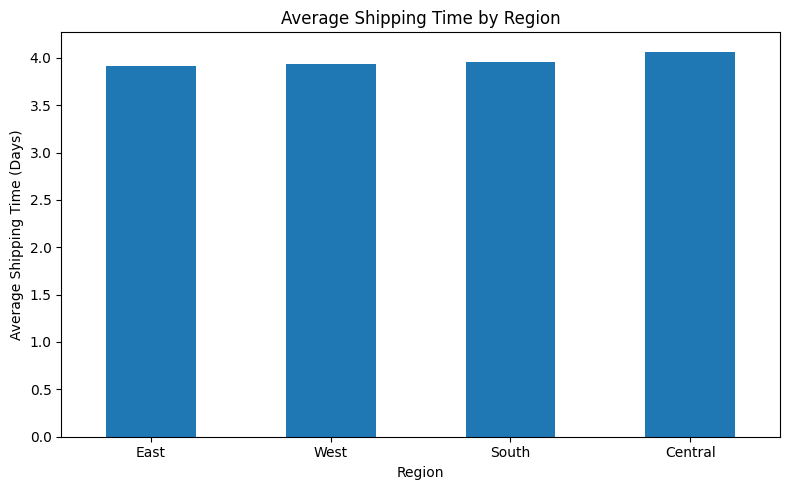

In [37]:
plt.figure(figsize=(8,5))
shipping_by_region.plot(kind="bar")
plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Time (Days)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/shipping_time_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The overall average shipping time is approximately **4 days**.
- Shipping times are fairly consistent across all regions, with only minor differences.
- The **East** region has the shortest average shipping time, while the **Central** region has the longest.
- Since the variation is very small, shipping performance appears to be consistent across the company's regional operations.

## Business Question 4: Are There Months That Consistently Spike Across All Years (Seasonality)?

In [32]:
monthly_trend = (df.groupby(["Year", "Month Name"])["Sales"].sum().reset_index())

In [33]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
monthly_trend["Month Name"] = pd.Categorical(monthly_trend["Month Name"],categories=month_order,ordered=True)
monthly_trend = monthly_trend.sort_values(["Year", "Month Name"])

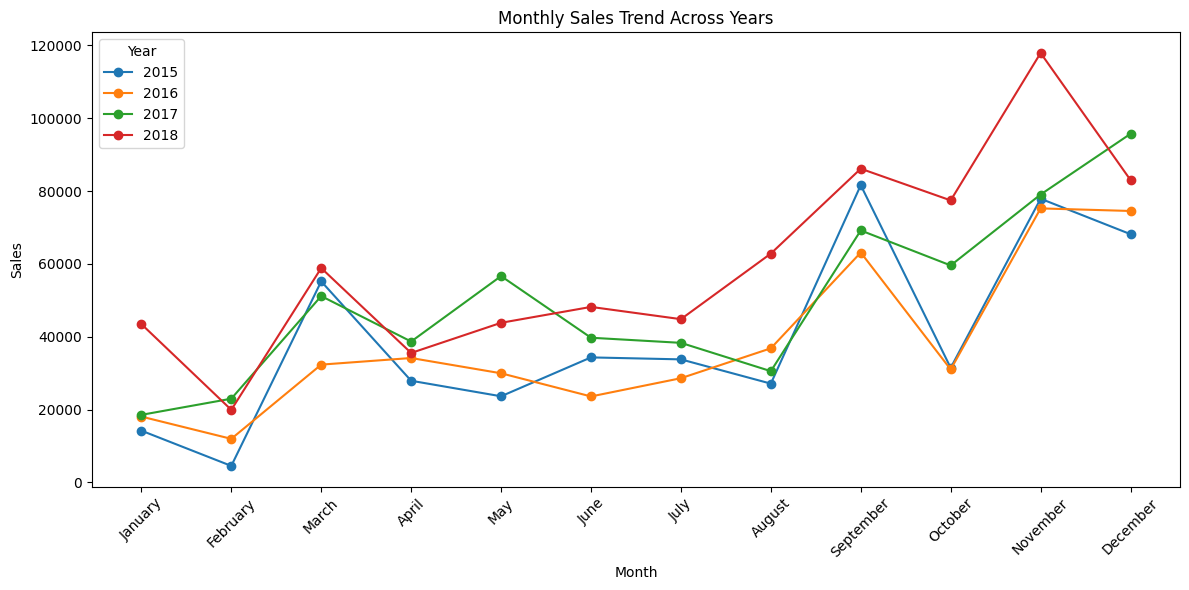

In [38]:
plt.figure(figsize=(12,6))
for year in monthly_trend["Year"].unique():
    temp = monthly_trend[monthly_trend["Year"] == year]
    plt.plot(
        temp["Month Name"],
        temp["Sales"],
        marker="o",
        label=year
    )
plt.title("Monthly Sales Trend Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend(title="Year")
plt.tight_layout()
plt.savefig("charts/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

### Observation

- Sales show clear seasonal patterns across all four years.
- **September, November, and December** consistently record higher sales than most other months.
- **November** experiences the highest sales in multiple years, indicating a strong seasonal demand, likely influenced by major shopping events and year-end purchasing.
- The recurring increase in sales during the last quarter suggests that inventory and supply chain planning should prioritize these months to meet higher customer demand.

# Task 2: Time Series Analysis & Decomposition

## Monthly Sales Trend Analysis

In [39]:
monthly_sales_ts = (df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum())
monthly_sales_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

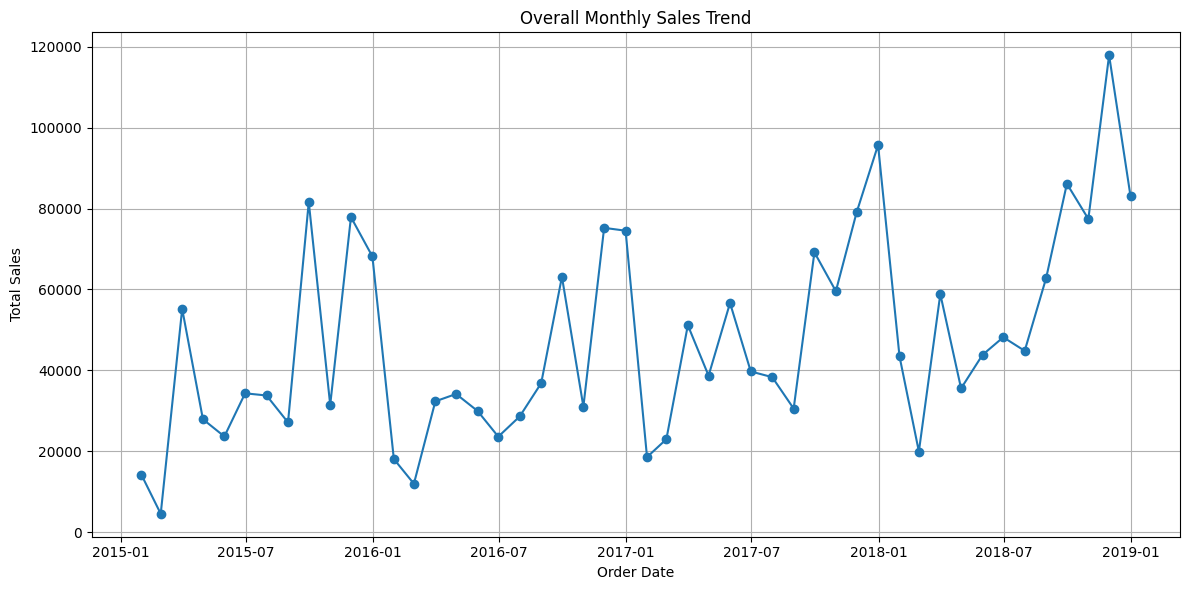

In [40]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts.values,
    marker="o"
)
plt.title("Overall Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/task2_monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- The monthly sales trend shows an overall upward trajectory from 2015 to 2018.
- Sales fluctuate considerably from month to month, indicating the presence of seasonality and irregular variations.
- The highest sales are observed towards the end of 2018, suggesting increasing customer demand over time.
- The recurring peaks and troughs indicate that the time series is likely composed of trend and seasonal components, making it suitable for time series decomposition.

## Time Series Decomposition

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [44]:
decomposition = seasonal_decompose(monthly_sales_ts,model="additive",period=12)

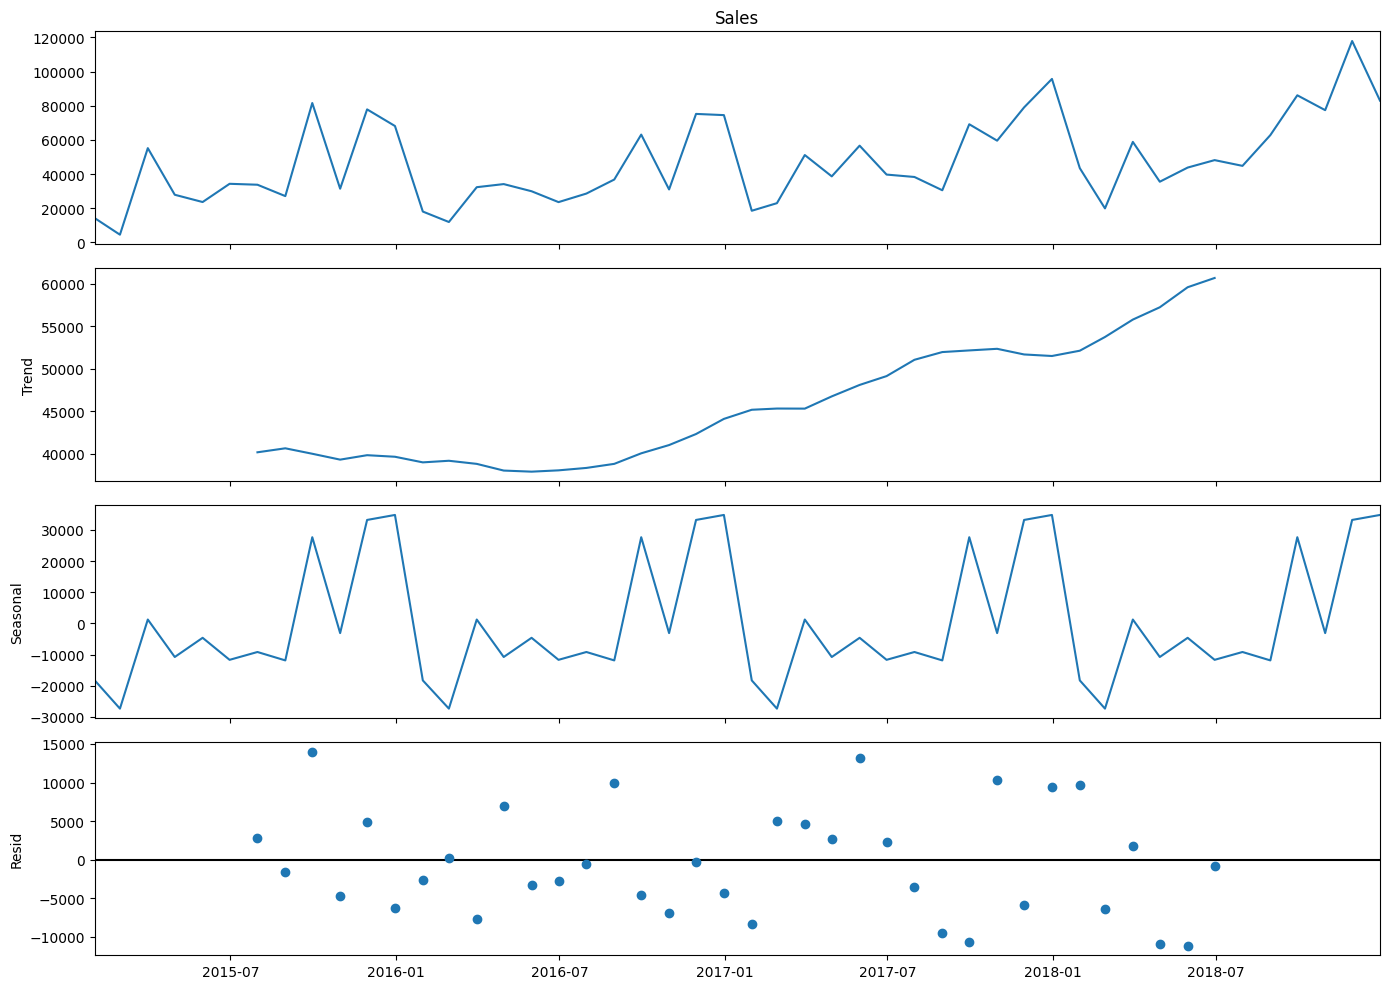

In [45]:
decomposition.plot()
plt.gcf().set_size_inches(14, 10)
plt.tight_layout()
plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- The **trend** component shows a gradual increase in sales over time, indicating overall business growth.
- The **seasonal** component reveals recurring monthly patterns, confirming that sales exhibit seasonality.
- The **residual** component contains irregular fluctuations that are not explained by the trend or seasonal patterns.
- The decomposition confirms that the sales data contains both trend and seasonal effects, making it suitable for forecasting using time series models such as SARIMA and Prophet.

## Augmented Dickey-Fuller (ADF) Stationarity Test

In [46]:
from statsmodels.tsa.stattools import adfuller

In [47]:
adf_result = adfuller(monthly_sales_ts)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations:", adf_result[3])
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Number of Lags Used: 0
Number of Observations: 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Observation

- The Augmented Dickey-Fuller (ADF) test returned a **p-value of 0.000278**, which is significantly lower than the 0.05 significance level.
- Therefore, the null hypothesis of non-stationarity is rejected.
- The monthly sales time series is **stationary** and suitable for time series forecasting without applying additional differencing.

# Task 3: Sales Forecasting Models

## Preparing Data for Forecasting

In [48]:
train = monthly_sales_ts[:-6]
test = monthly_sales_ts[-6:]
print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 42
Testing observations: 6


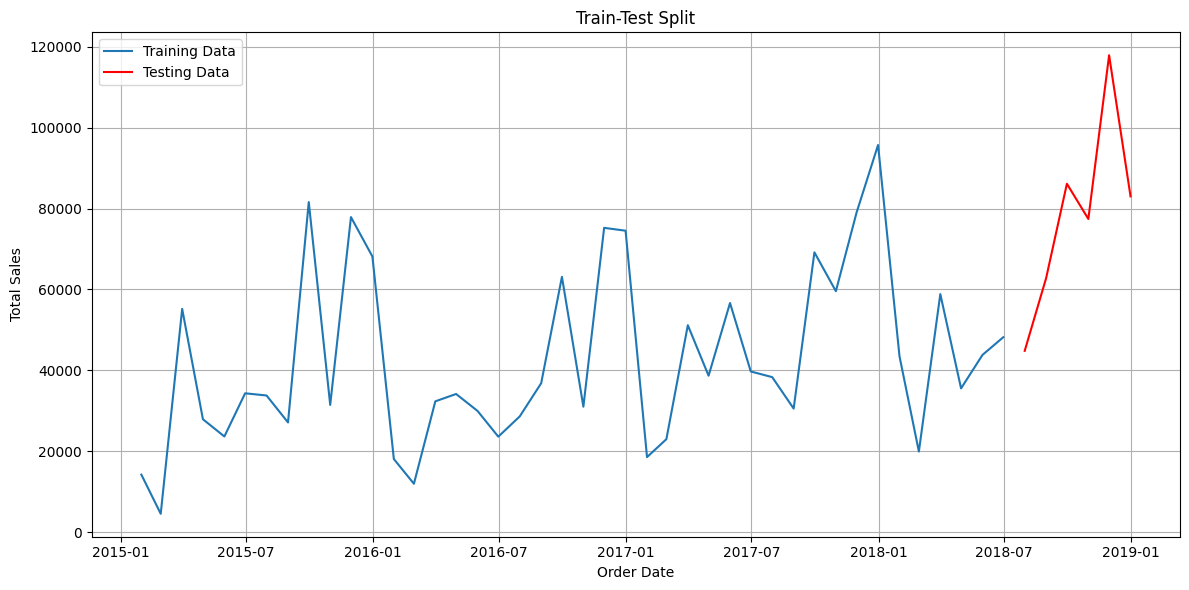

In [49]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train.values, label="Training Data")
plt.plot(test.index, test.values, label="Testing Data", color="red")
plt.title("Train-Test Split")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/train_test_split.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The dataset was divided into training and testing sets using a chronological split, with the last six months reserved for testing. This preserves the temporal order of the data, prevents data leakage, and enables an unbiased evaluation of the forecasting models on unseen data.

## Model 1: SARIMA Forecasting

In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (mean_absolute_error,mean_squared_error)
import numpy as np

In [51]:
sarima_model = SARIMAX(train,order=(1,1,1),seasonal_order=(1,1,1,12),enforce_stationarity=False,enforce_invertibility=False)
sarima_result = sarima_model.fit()

In [52]:
sarima_forecast = sarima_result.forecast(steps=len(test))
sarima_forecast

2018-07-31    46764.175422
2018-08-31    44026.234015
2018-09-30    79134.823051
2018-10-31    59810.397106
2018-11-30    88311.900743
2018-12-31    97171.990111
Freq: ME, Name: predicted_mean, dtype: float64

In [56]:
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mape = np.mean(np.abs((test - sarima_forecast) / test)) * 100
print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")

MAE  : 14862.39
RMSE : 17299.71
MAPE : 17.89%


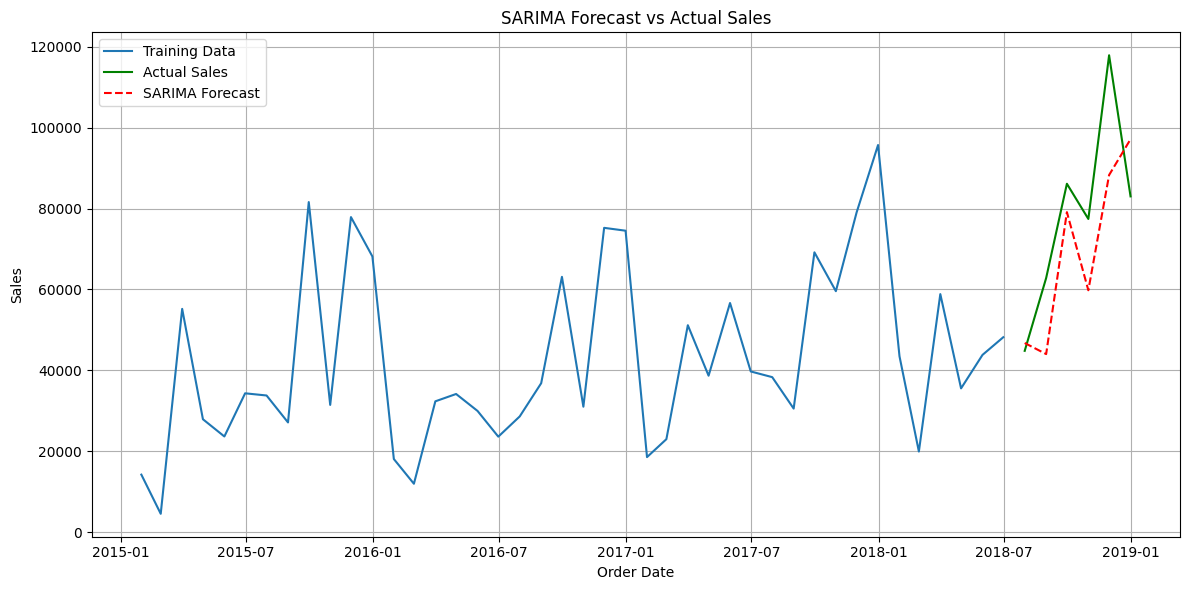

In [54]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Sales", color="green")
plt.plot(test.index,sarima_forecast,label="SARIMA Forecast",color="red",linestyle="--")
plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/sarima_forecast.png",dpi=300,bbox_inches="tight")
plt.show()

### Observation

- The SARIMA model successfully captured the overall sales trend during the testing period.
- The forecast closely follows the direction of the actual sales but underestimates the sharp sales peak observed in one of the test months.
- The model achieved an **MAE of 14,862.39**, **RMSE of 17,299.71**, and **MAPE of 17.89%**, indicating a reasonably accurate baseline forecasting performance.

## Model 2: Prophet Forecasting

In [58]:
from prophet import Prophet

In [59]:
prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]
prophet_train.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [60]:
prophet_model = Prophet()
prophet_model.fit(prophet_train)

11:07:02 - cmdstanpy - INFO - Chain [1] start processing
11:07:02 - cmdstanpy - INFO - Chain [1] done processing


In [61]:
future = prophet_model.make_future_dataframe(periods=len(test),freq="ME")

In [62]:
forecast = prophet_model.predict(future)
forecast[["ds", "yhat"]].tail()

,ds,yhat
43,2018-08-31,39501.249689
44,2018-09-30,85719.773846
45,2018-10-31,50154.845381
46,2018-11-30,89049.215969
47,2018-12-31,88623.102096


In [63]:
prophet_forecast= forecast["yhat"].tail(len(test)).values

In [64]:
prophet_mae = mean_absolute_error(test, prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_forecast))
prophet_mape = np.mean(np.abs((test - prophet_forecast) / test)) * 100
print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape:.2f}%")

MAE  : 14309.99
RMSE : 18954.58
MAPE : 17.47%


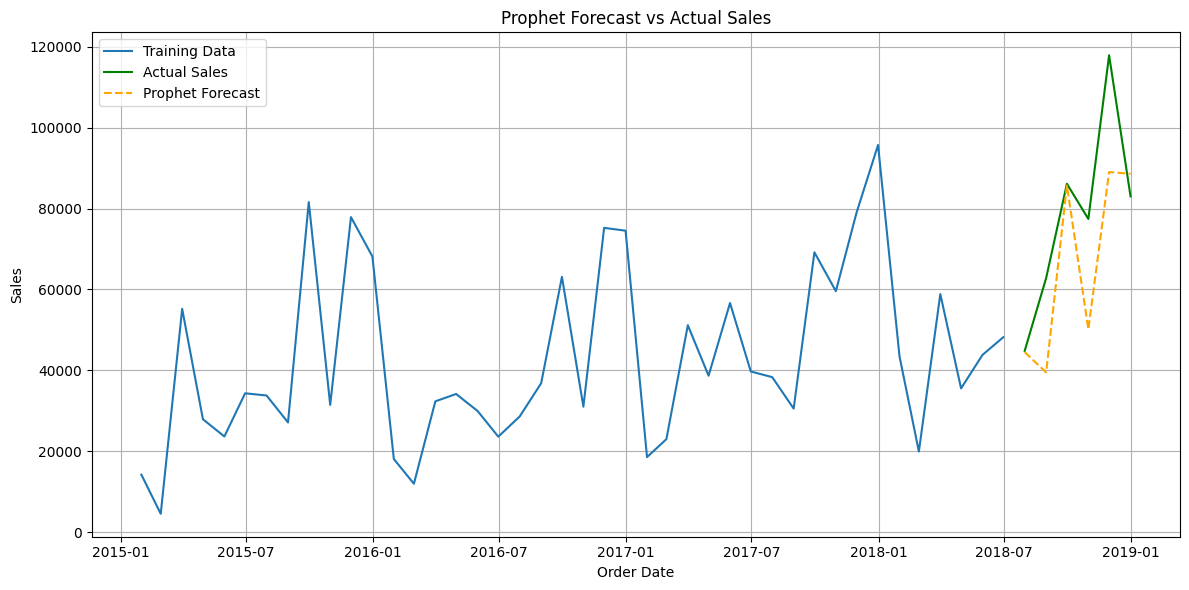

In [65]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Sales", color="green")
plt.plot(
    test.index,
    prophet_forecast,
    label="Prophet Forecast",
    color="orange",
    linestyle="--"
)
plt.title("Prophet Forecast vs Actual Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/prophet_forecast.png",dpi=300,bbox_inches="tight")
plt.show()

### Observation

- The Prophet model successfully captured the overall direction of sales during the testing period.
- Similar to SARIMA, it underestimated the highest sales peak but followed the general trend reasonably well.
- The model achieved an **MAE of 14,309.99**, **RMSE of 18,954.58**, and **MAPE of 17.47%**.
- Compared with SARIMA, Prophet produced slightly lower MAE and MAPE values, indicating a small improvement in average forecasting accuracy.

## Model 3: XGBoost Forecasting

In [66]:
from xgboost import XGBRegressor

In [67]:
xgb_df = monthly_sales_ts.to_frame(name="Sales")
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)
xgb_df = xgb_df.dropna()
xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3
Order Date,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303


In [68]:
X = xgb_df[["Lag_1", "Lag_2", "Lag_3"]]
y = xgb_df["Sales"]
X_train = X[:-6]
X_test = X[-6:]
y_train = y[:-6]
y_test = y[-6:]

In [69]:
xgb_model = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [70]:
xgb_forecast = xgb_model.predict(X_test)

In [71]:
xgb_mae = mean_absolute_error(y_test, xgb_forecast)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_forecast))
xgb_mape = np.mean(np.abs((y_test - xgb_forecast) / y_test)) * 100
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAPE : {xgb_mape:.2f}%")

MAE  : 32838.03
RMSE : 35878.90
MAPE : 40.02%


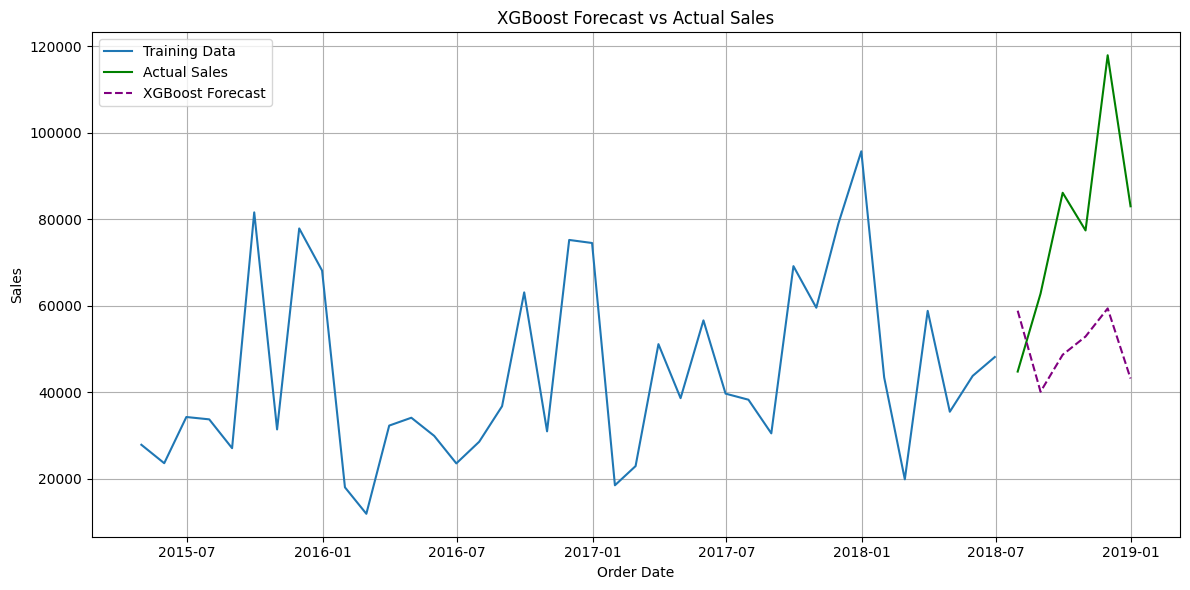

In [72]:
plt.figure(figsize=(12,6))
plt.plot(
    y_train.index,
    y_train,
    label="Training Data"
)
plt.plot(
    y_test.index,
    y_test,
    label="Actual Sales",
    color="green"
)
plt.plot(
    y_test.index,
    xgb_forecast,
    label="XGBoost Forecast",
    color="purple",
    linestyle="--"
)

plt.title("XGBoost Forecast vs Actual Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/xgboost_forecast.png",dpi=300,bbox_inches="tight")
plt.show()

### Observation

- The XGBoost model produced less accurate forecasts compared to the SARIMA and Prophet models.
- It struggled to capture the increasing sales trend and substantially underestimated the higher sales values during the testing period.
- The model achieved an **MAE of 32,838.03**, **RMSE of 35,878.90**, and **MAPE of 40.02%**, making it the least accurate forecasting model among the three evaluated approaches.

## Model Performance Comparison

In [73]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [sarima_mae, prophet_mae, xgb_mae],
    "RMSE": [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE": [sarima_mape, prophet_mape, xgb_mape]
})
comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,14862.390003,17299.708799,17.889047
1,Prophet,14309.986950,18954.579462,17.469222
2,XGBoost,32838.032286,35878.901767,40.024749


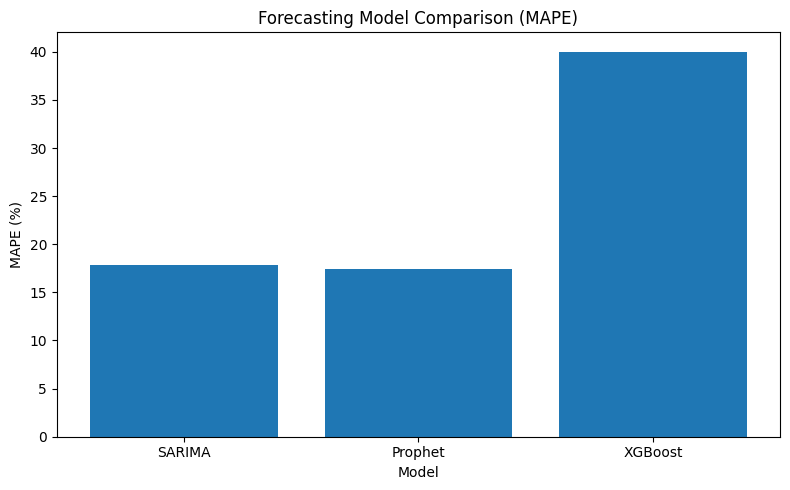

In [74]:
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["MAPE"])
plt.title("Forecasting Model Comparison (MAPE)")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.tight_layout()
plt.savefig("charts/model_comparison.png",dpi=300,bbox_inches="tight")
plt.show()

### Observation

- Among the three forecasting models, **Prophet** achieved the lowest MAE and MAPE, indicating the best overall forecasting performance.
- **SARIMA** also performed well and recorded the lowest RMSE, making it a strong alternative.
- **XGBoost** showed considerably higher forecasting errors, suggesting that tree-based models may require more historical observations and additional engineered features to effectively model this monthly sales dataset.

# Task 4: Category & Region-wise Forecasting

## Category-wise Monthly Sales Forecasting

In [75]:
category_monthly = (
    df.groupby([
        pd.Grouper(key="Order Date", freq="ME"),
        "Category"
    ])["Sales"]
    .sum()
    .reset_index()
)
category_monthly.head()

,Order Date,Category,Sales
0,2015-01-31,Furniture,6217.277
1,2015-01-31,Office Supplies,4845.140
2,2015-01-31,Technology,3143.290
3,2015-02-28,Furniture,1839.658
4,2015-02-28,Office Supplies,1071.724


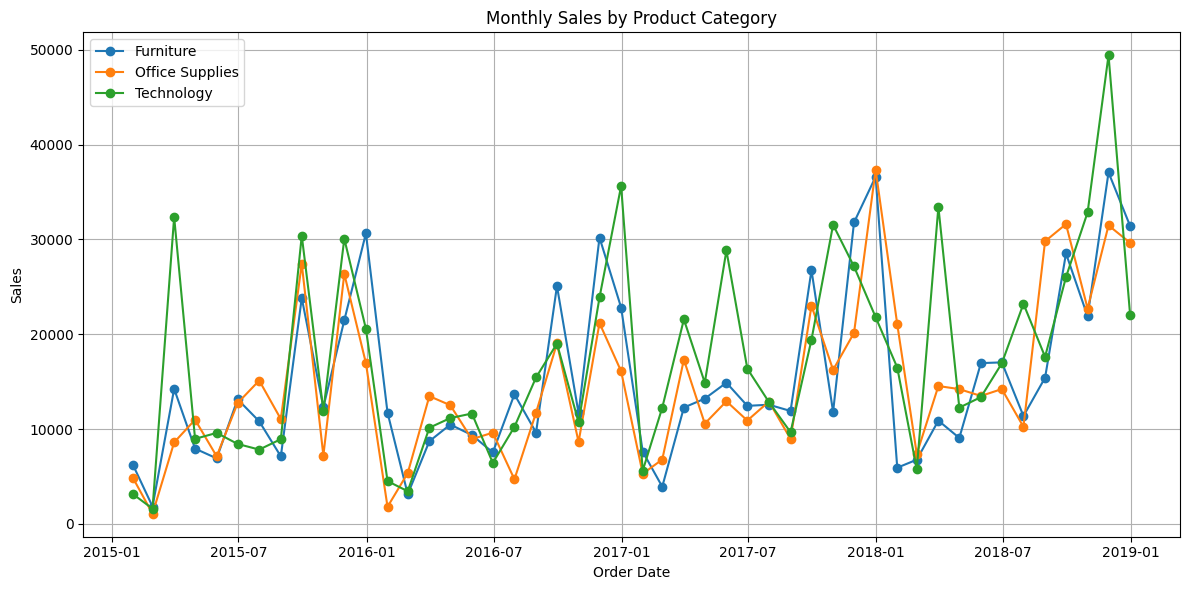

In [76]:
plt.figure(figsize=(12,6))
for category in category_monthly["Category"].unique():
    temp = category_monthly[
        category_monthly["Category"] == category
    ]
    plt.plot(
        temp["Order Date"],
        temp["Sales"],
        marker="o",
        label=category
    )
plt.title("Monthly Sales by Product Category")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/category_monthly_sales.png",dpi=300,bbox_inches="tight")
plt.show()

### Observation

- All three product categories exhibit noticeable month-to-month fluctuations, indicating seasonal variations in sales.
- **Technology** shows the highest sales peaks during several months, particularly toward the end of the observed period.
- **Furniture** demonstrates relatively stable sales with moderate fluctuations.
- **Office Supplies** maintains consistent performance throughout the years but generally records lower peak sales than Technology.
- Overall, Technology appears to have the strongest growth potential among the three categories.

## Region-wise Monthly Sales Forecasting

In [77]:
region_monthly = (
    df.groupby([
        pd.Grouper(key="Order Date", freq="ME"),
        "Region"
    ])["Sales"]
    .sum()
    .reset_index()
)
region_monthly.head()

,Order Date,Region,Sales
0,2015-01-31,Central,1533.966
1,2015-01-31,East,436.174
2,2015-01-31,South,9296.844
3,2015-01-31,West,2938.723
4,2015-02-28,Central,1233.174


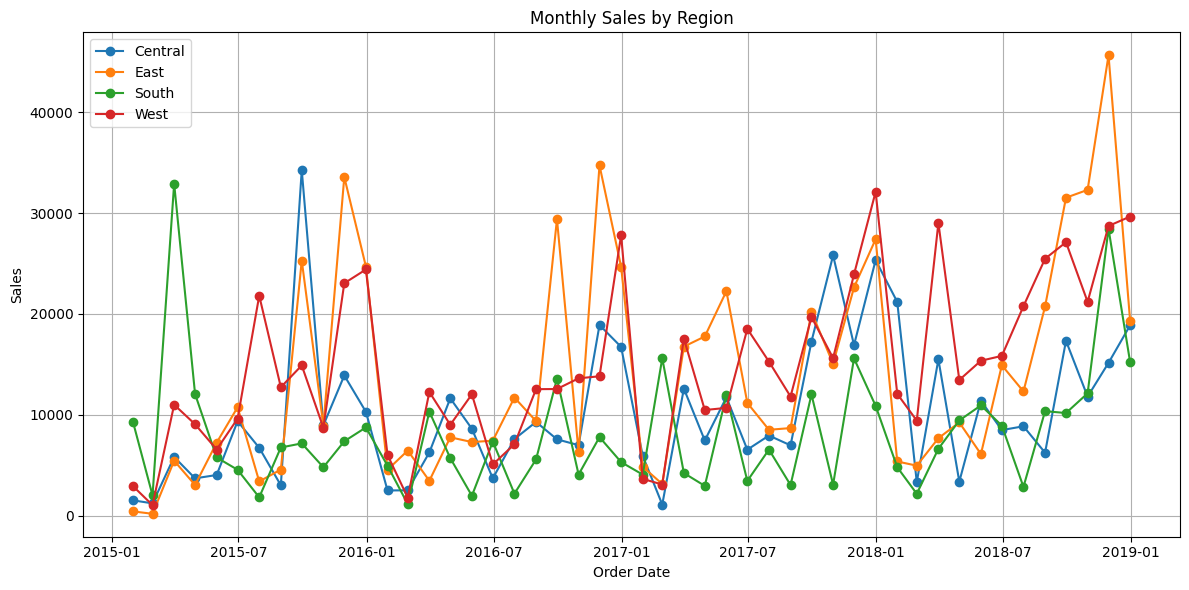

In [78]:
plt.figure(figsize=(12,6))
for region in region_monthly["Region"].unique():
    temp = region_monthly[
        region_monthly["Region"] == region
    ]
    plt.plot(
        temp["Order Date"],
        temp["Sales"],
        marker="o",
        label=region
    )
plt.title("Monthly Sales by Region")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/region_monthly_sales.png",dpi=300,bbox_inches="tight")
plt.show()

### Observation

- The **West** and **East** regions consistently generate higher monthly sales than the Central and South regions.
- The **West** region shows strong growth during the later months, while the **East** region records the highest individual monthly sales peak.
- The **Central** region exhibits moderate and relatively stable sales throughout the period.
- The **South** region generally records the lowest monthly sales, although it experiences a few noticeable spikes.
- Overall, regional sales patterns indicate that demand varies considerably across regions, making region-specific forecasting valuable for business planning.

## Category-wise Sales Forecasting using Prophet

In [79]:
def prophet_forecast_segment(data, segment_column, segment_name, periods=6):
    segment_data = data[data[segment_column] == segment_name].copy()

    prophet_df = segment_data.rename(
        columns={"Order Date": "ds", "Sales": "y"}
    )[["ds", "y"]]

    model = Prophet()
    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=periods, freq="ME")
    forecast = model.predict(future)

    fig = model.plot(forecast)
    plt.title(f"{segment_name} Sales Forecast")
    plt.tight_layout()
    plt.show()

    return forecast

12:08:44 - cmdstanpy - INFO - Chain [1] start processing
12:08:44 - cmdstanpy - INFO - Chain [1] done processing


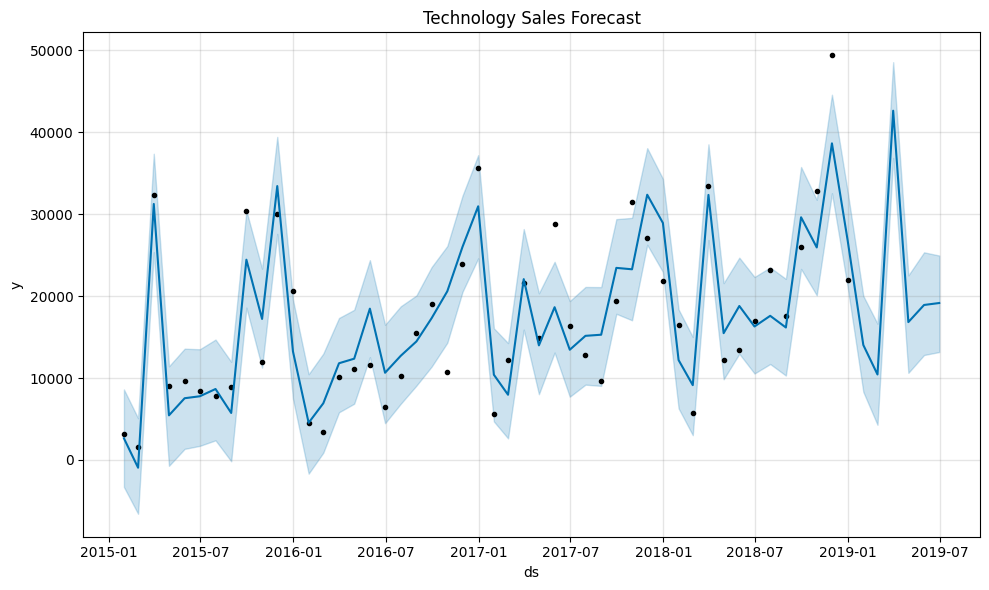

In [81]:
technology_forecast = prophet_forecast_segment(
    category_monthly,
    "Category",
    "Technology"
)

### Observation

- Technology is expected to maintain an upward sales trend over the forecast period.
- Although monthly fluctuations continue, the overall demand remains strong.
- This suggests that Technology products are likely to remain the highest revenue-generating category.

12:09:25 - cmdstanpy - INFO - Chain [1] start processing
12:09:25 - cmdstanpy - INFO - Chain [1] done processing


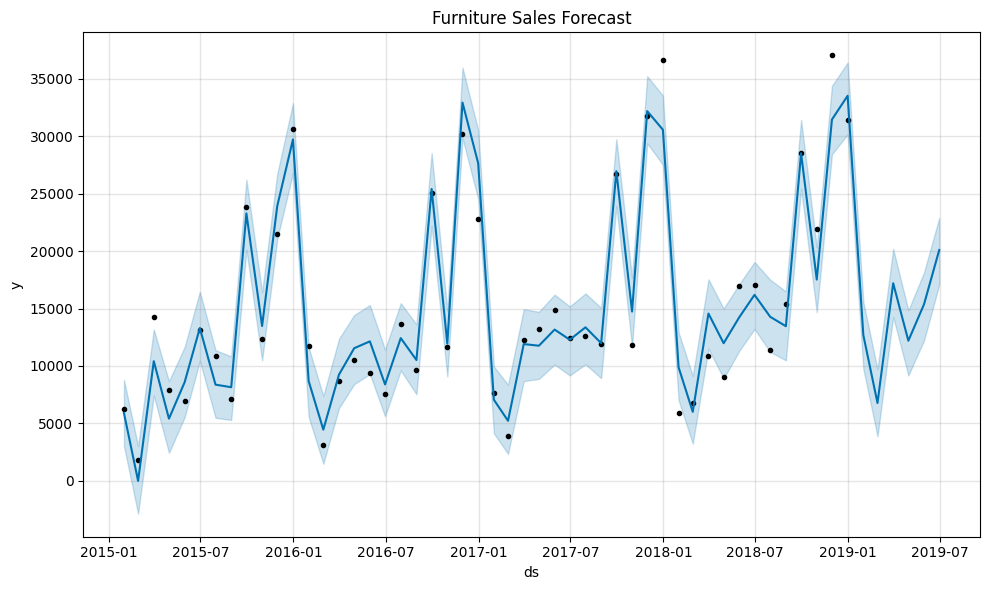

In [82]:
furniture_forecast = prophet_forecast_segment(
    category_monthly,
    "Category",
    "Furniture"
)

### Observation

- Furniture sales are forecasted to grow gradually with moderate seasonal fluctuations.
- Demand appears relatively stable compared to the Technology category.

12:09:38 - cmdstanpy - INFO - Chain [1] start processing
12:09:39 - cmdstanpy - INFO - Chain [1] done processing


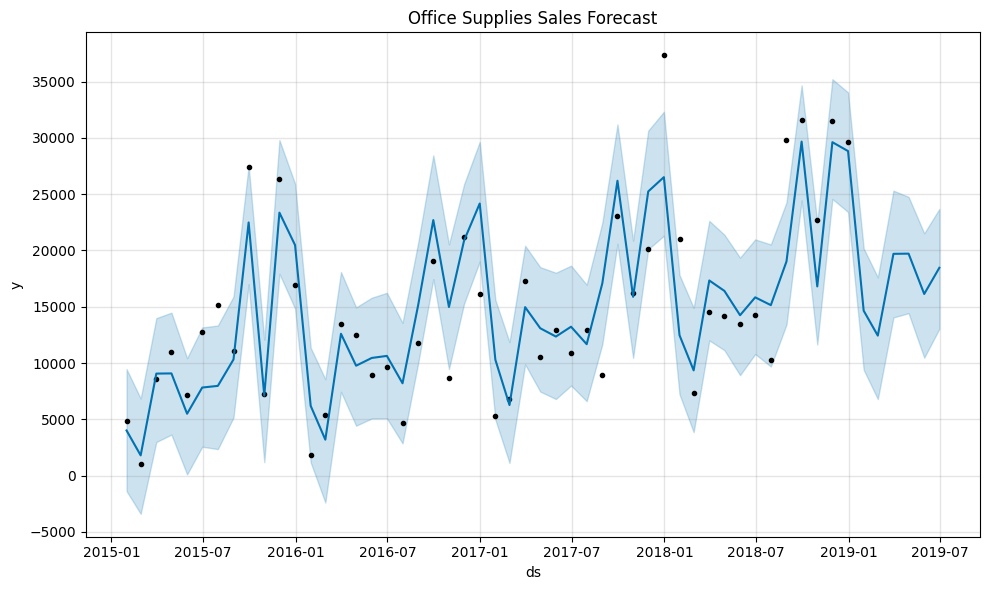

In [83]:
office_forecast = prophet_forecast_segment(
    category_monthly,
    "Category",
    "Office Supplies"
)

### Observation

- Office Supplies are expected to maintain steady sales with recurring seasonal variations.
- The forecast indicates consistent demand without major upward or downward shifts.

## Region-wise Sales Forecasting using Prophet

12:13:16 - cmdstanpy - INFO - Chain [1] start processing
12:13:16 - cmdstanpy - INFO - Chain [1] done processing


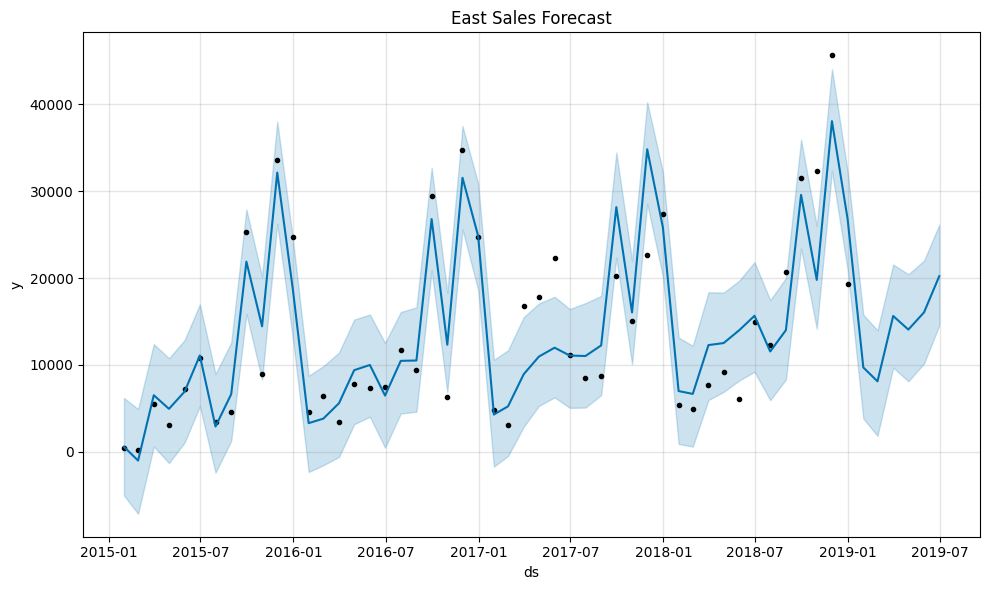

In [85]:
east_forecast = prophet_forecast_segment(
    region_monthly,
    "Region",
    "East"
)

### Observation

- The East region is forecasted to maintain strong sales performance with continued growth over the forecast horizon.
- Seasonal fluctuations remain visible, but the overall trend is positive.

12:13:23 - cmdstanpy - INFO - Chain [1] start processing
12:13:24 - cmdstanpy - INFO - Chain [1] done processing


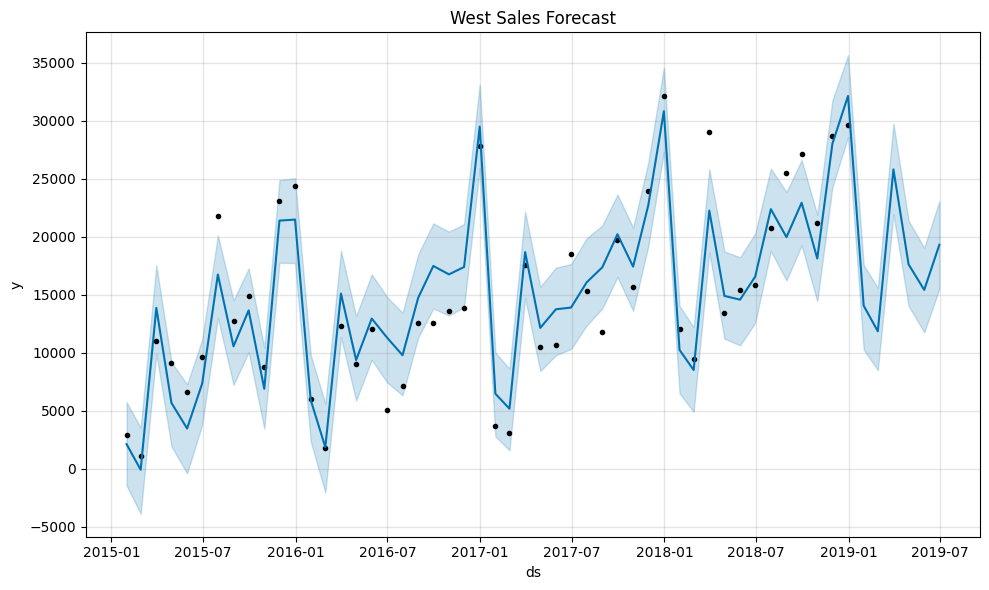

In [86]:
west_forecast = prophet_forecast_segment(
    region_monthly,
    "Region",
    "West"
)

### Observation

- The West region is expected to continue generating high sales with moderate fluctuations.
- The forecast indicates sustained customer demand and strong regional performance.

12:13:33 - cmdstanpy - INFO - Chain [1] start processing
12:13:33 - cmdstanpy - INFO - Chain [1] done processing


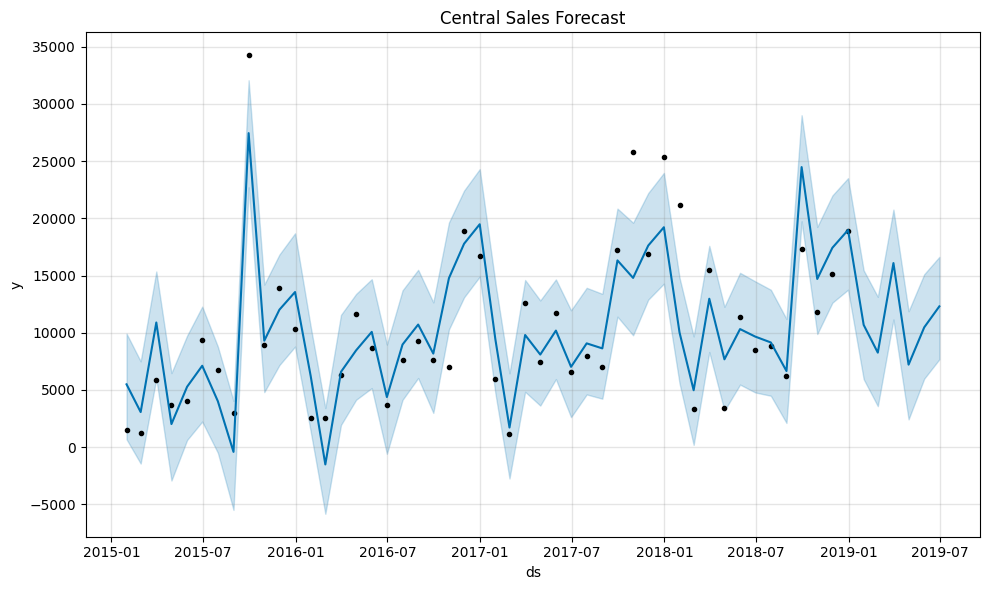

In [88]:
central_forecast = prophet_forecast_segment(
    region_monthly,
    "Region",
    "Central"
)

### Observation

- Central region sales are forecasted to remain relatively stable with gradual growth.
- Demand is consistent but lower than the East and West regions.

12:13:31 - cmdstanpy - INFO - Chain [1] start processing
12:13:31 - cmdstanpy - INFO - Chain [1] done processing


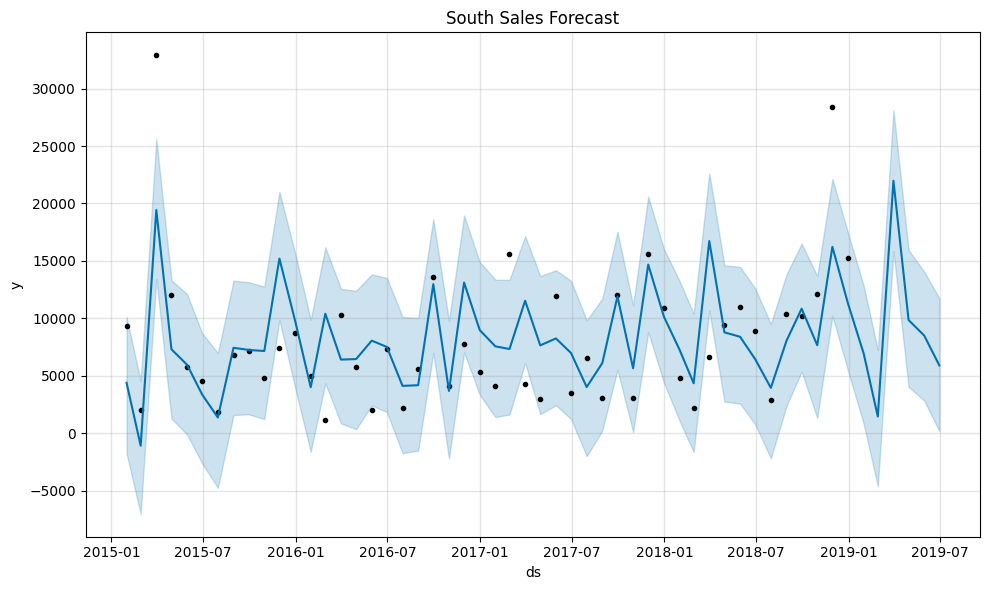

In [87]:
south_forecast = prophet_forecast_segment(
    region_monthly,
    "Region",
    "South"
)

### Observation

- The South region is expected to maintain steady sales with periodic fluctuations.
- Although overall demand is lower than other regions, the forecast does not indicate a significant decline.

## Task 4 Summary

Category-wise and region-wise forecasting was performed using the Prophet model. The forecasts indicate that the **Technology** category is expected to remain the strongest contributor to future sales, while the **East** and **West** regions are projected to continue leading regional performance. These forecasts can support inventory planning, regional resource allocation, and demand management.

# Task 5: Sales Anomaly Detection

## Anomaly Detection using Z-Score

In [89]:
from scipy.stats import zscore

In [90]:
anomaly_df = monthly_sales_ts.to_frame(name="Sales")
anomaly_df["Z-Score"] = zscore(anomaly_df["Sales"])
anomaly_df["Anomaly"] = anomaly_df["Z-Score"].abs() > 2
anomaly_df.head()

,Sales,Z-Score,Anomaly
Order Date,,,
2015-01-31,14205.707,-1.331451,False
2015-02-28,4519.892,-1.723318,False
2015-03-31,55205.797,0.327322,False
2015-04-30,27906.855,-0.777133,False
2015-05-31,23644.303,-0.949587,False


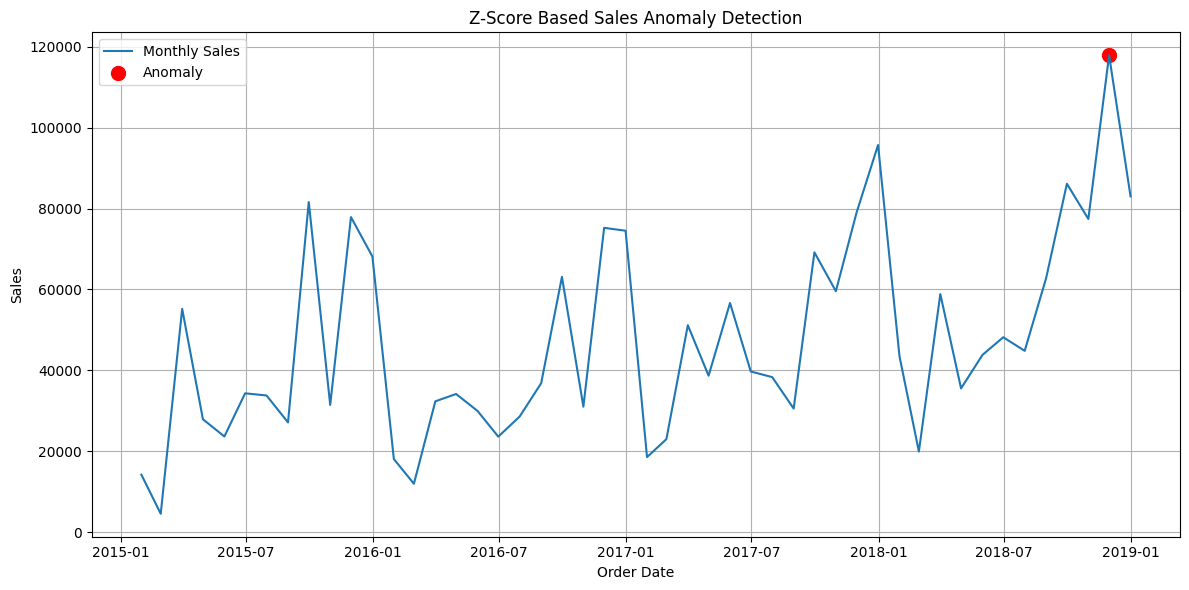

In [91]:
plt.figure(figsize=(12,6))
plt.plot(
    anomaly_df.index,
    anomaly_df["Sales"],
    label="Monthly Sales"
)
plt.scatter(
    anomaly_df[anomaly_df["Anomaly"]].index,
    anomaly_df[anomaly_df["Anomaly"]]["Sales"],
    color="red",
    s=100,
    label="Anomaly"
)
plt.title("Z-Score Based Sales Anomaly Detection")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/zscore_anomalies.png",dpi=300,bbox_inches="tight")
plt.show()

### Observation

- The Z-Score method identified one significant sales anomaly during the observed period.
- The detected anomaly corresponds to the highest monthly sales value, indicating an unusually large sales spike compared to the overall distribution.
- This method is effective at identifying extreme outliers but may not detect more subtle abnormal sales patterns.

## Anomaly Detection using Isolation Forest

In [92]:
from sklearn.ensemble import IsolationForest

In [93]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)
anomaly_df["Isolation"] = iso_model.fit_predict(
    anomaly_df[["Sales"]]
)
anomaly_df["Isolation"] = anomaly_df["Isolation"].map({
    1: False,
    -1: True
})
anomaly_df.head()

,Sales,Z-Score,Anomaly,Isolation
Order Date,,,,
2015-01-31,14205.707,-1.331451,False,False
2015-02-28,4519.892,-1.723318,False,True
2015-03-31,55205.797,0.327322,False,False
2015-04-30,27906.855,-0.777133,False,False
2015-05-31,23644.303,-0.949587,False,False


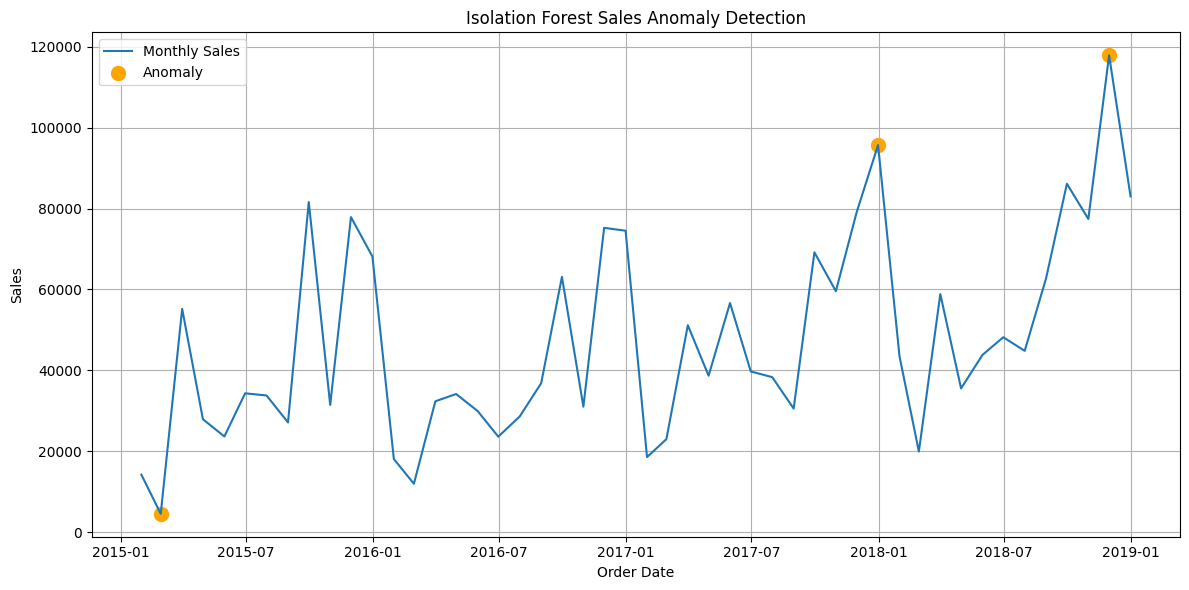

In [94]:
plt.figure(figsize=(12,6))
plt.plot(
    anomaly_df.index,
    anomaly_df["Sales"],
    label="Monthly Sales"
)
plt.scatter(
    anomaly_df[anomaly_df["Isolation"]].index,
    anomaly_df[anomaly_df["Isolation"]]["Sales"],
    color="orange",
    s=100,
    label="Anomaly"
)
plt.title("Isolation Forest Sales Anomaly Detection")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/isolation_forest_anomalies.png",dpi=300,bbox_inches="tight")
plt.show()

### Observation

- The Isolation Forest algorithm identified multiple anomalous months, including both unusually low and unusually high sales values.
- Compared to the Z-Score method, Isolation Forest detected a broader range of abnormal observations by considering the overall data distribution rather than only extreme statistical deviations.
- This makes Isolation Forest more suitable for identifying complex sales anomalies that may not be detected using simple statistical thresholds.

# Task 6: Product Clustering & Demand Segmentation

## Product-Level Sales Aggregation

In [105]:
product_features = (
    df.groupby("Product Name")
      .agg(
          Total_Sales=("Sales", "sum"),
          Average_Sales=("Sales", "mean"),
          Order_Count=("Sales", "count")
      )
      .reset_index()
)
product_features.head()

,Product Name,Total_Sales,Average_Sales,Order_Count
0,"""While you Were Out"" Message Book, One Form pe...",25.228,8.409333,3
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,10.325000,4
2,#10 Self-Seal White Envelopes,108.682,27.170500,4
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,63.202333,6
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,28.667200,10


## Feature Scaling

In [106]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    product_features[
        ["Total_Sales", "Average_Sales", "Order_Count"]
    ]
)

## Finding the Optimal Number of Clusters

In [99]:
from sklearn.cluster import KMeans

In [107]:
inertia = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

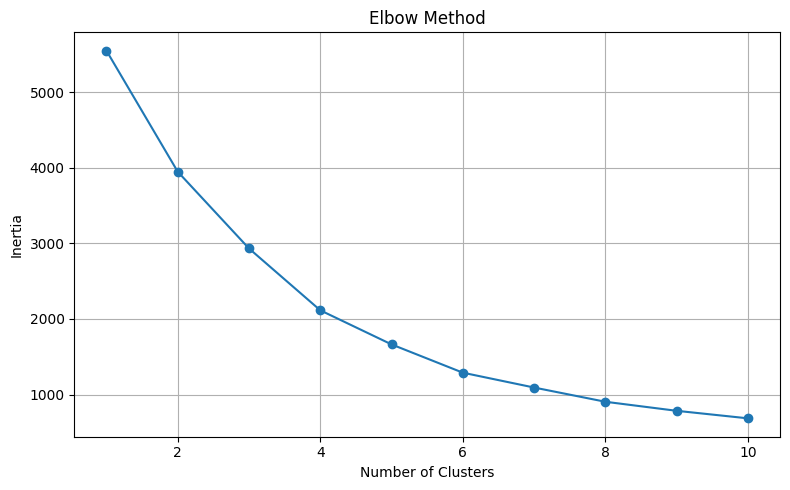

In [108]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The elbow plot indicates that **4** clusters provide an optimal balance between model complexity and within-cluster variance. Therefore, **k = 4** was selected for product segmentation.

## Product Clustering using K-Means

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
product_features["Cluster"] = kmeans.fit_predict(
    scaled_features
)
product_features.head()

,Product Name,Total_Sales,Average_Sales,Order_Count,Cluster
0,"""While you Were Out"" Message Book, One Form pe...",25.228,8.409333,3,0
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,10.325000,4,0
2,#10 Self-Seal White Envelopes,108.682,27.170500,4,0
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,63.202333,6,1
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,28.667200,10,1


## Cluster Visualization using PCA

In [110]:
from sklearn.decomposition import PCA

In [111]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

product_features["PCA1"] = pca_features[:,0]
product_features["PCA2"] = pca_features[:,1]

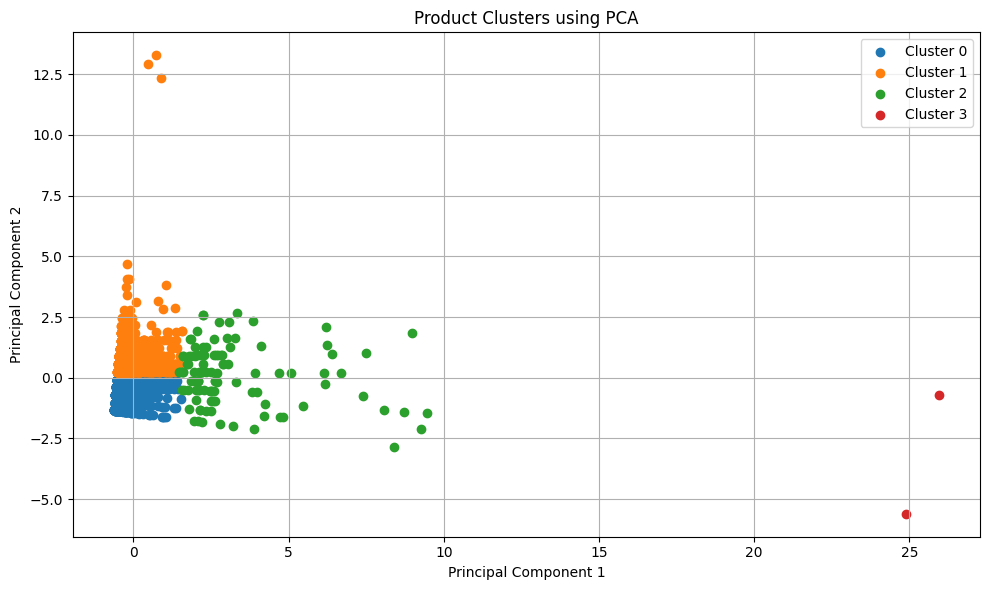

In [114]:
plt.figure(figsize=(10,6))
for cluster in sorted(product_features["Cluster"].unique()):

    temp = product_features[
        product_features["Cluster"] == cluster
    ]

    plt.scatter(
        temp["PCA1"],
        temp["PCA2"],
        label=f"Cluster {cluster}"
    )
plt.title("Product Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/product_clusters.png",dpi=300,bbox_inches="tight")
plt.show()

In [113]:
product_features.groupby("Cluster")[["Total_Sales", "Average_Sales", "Order_Count"]].mean()

,Total_Sales,Average_Sales,Order_Count
Cluster,,,
0,547.129085,164.006799,3.491279
1,981.502231,128.919893,7.855524
2,8437.804471,1811.769111,5.917431
3,42119.152000,17479.222400,3.000000


### Observation

- Four product clusters were identified using K-Means clustering.
- Products within the same cluster share similar sales characteristics based on total sales, average sales, and order frequency.
- The segmentation helps identify high-performing, moderate-performing, and low-performing product groups, which can support inventory planning and targeted marketing strategies.

## Task 6 Summary

Products were segmented into four clusters using K-Means clustering based on total sales, average sales, and order count. PCA was used to visualize the clusters in two dimensions, making it easier to interpret the product segments. These insights can help improve inventory management, demand planning, and business decision-making.